# Temporal · single-field — pipeline demo template

The **temporal single-field** template.  Every demo in this group follows the same three steps — **load → run → plot** — all driven by [`daedalus.py`](../daedalus.py):

1. **Load** a theory from `theories/<name>.theory.py` (the single source of truth — no inline model building).
2. **Run** it with one `dd.Config(...)`: the correlator order `k`, the loop order `max_ell`, the Dyson order, the grids, and every plotting option live there.
3. **Plot** with `dd.plot_cumulant`, which auto-dispatches to the form natural to this group.

This template ships with **`ou_quartic_double_well`**.  To demo a different temporal theory, set `THEORY` below to any single-field temporal `theories/*.theory.py` (e.g. `ou_sextic`, `single_population_spike_reset_test`).  Everything else is identical across all four group templates on purpose — common thematics for the demos.

## 1. Setup

In [1]:
%matplotlib inline
import os, sys
import numpy as np
import matplotlib.pyplot as plt
# depth-robust repo root: walk up until the 'pipeline' package is found
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'pipeline')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
sys.path.insert(0, os.path.join(_root, 'notebooks'))
import daedalus as dd
print('daedalus \u2192', dd.REPO_ROOT)

daedalus → /Users/matthewszuromi/Documents/Education/BU PhD/Ocker Lab/Automated Feynman Calculations


## 2. Choose the theory & configure the run

This is the only cell you edit.  `k` and `max_ell` are free (arbitrary correlator order and loop order); the plotting options (`show_orders`, `logy`, `figsize`, …) are adaptable.

In [2]:
THEORY = 'ou_quartic_double_well'   # any single-field temporal theory

cfg = dd.Config(
    # --- what to compute (arbitrary k and loop order) ---
    k=2,            # 2 = ⟨xx⟩, 3 = ⟨xxx⟩, …
    max_ell=1,      # 0 = tree, 1 = +1-loop, 2 = +2-loop, …
    # external_fields=[('dx', 1), ('dx', 1)],   # None → auto from theory

    # --- temporal grid ---
    tau_max=4.0,
    tau_step=1.0,

    # --- plotting (adaptable) ---
    show_orders='cumulative',   # 'cumulative' | 'incremental' | 'total'
    logy=False,
)

In [3]:
model, mod = dd.load_theory(THEORY)
print('loaded :', model.get('name'))
print('fields :', dd.field_names(model),
      '| spatial_dim:', dd.spatial_dim(model),
      '| multi-field:', dd.is_multifield(model))
print('params :', [p['name'] for p in (model.get('parameters') or [])])

loaded : OU Quartic Double Well
fields : ['dx'] | spatial_dim: 0 | multi-field: False
params : ['xstar', 'mu', 'eps', 'D']


## 3. Run

In [4]:
res = dd.run(model, cfg, mod)
print(dd.summary(res))

theory : 'OU Quartic Double Well'
k      : 2    max_ell : 1
fields : ['dx']   spatial_dim : 0


## 4. Plot

`show_orders` controls the per-loop-order overlay: `'cumulative'` (tree, tree+1-loop, …), `'incremental'` (each order alone), or `'total'` (the summed result only).

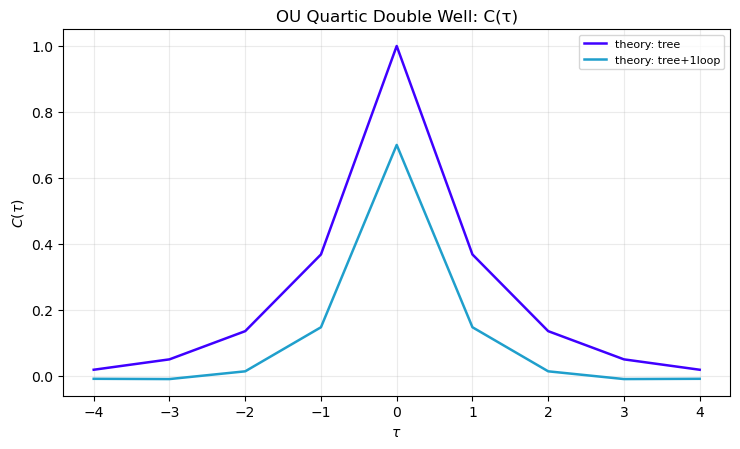

In [5]:
fig = dd.plot_cumulant(res, cfg, model)
plt.show()